In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 9,                    # Base font size
    "axes.labelsize": 9,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})

import pickle


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making


/Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making/basal_ganglia/train.py:12: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Case-1 Easy scheme

### Individual runs

In [2]:
# Case-1
data_normal_file_v1 = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'Case_1_Easy', 'non_stationary_bandits_v1_normal.pkl')

with open(data_normal_file_v1, 'rb') as f:
    data_normal_v1 = pickle.load(f)

print(data_normal_v1.keys())

# load PD

data_PD_file_v1 = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'Case_1_Easy','non_stationary_bandits_v1_PD.pkl')

with open(data_PD_file_v1, 'rb') as f:
    data_PD_v1 = pickle.load(f)

# load std_DBS

data_std_DBS_file_v1 = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'Case_1_Easy','non_stationary_bandits_v1_std_DBS.pkl')

with open(data_std_DBS_file_v1, 'rb') as f:
    data_std_DBS_v1 = pickle.load(f)

# load sector_DBS

data_sector_DBS_file_v1 = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'Case_1_Easy', 'non_stationary_bandits_v1_sector_DBS.pkl')

with open(data_sector_DBS_file_v1, 'rb') as f:
    data_sector_DBS_v1 = pickle.load(f)


dict_keys(['DP_AVG', 'IP_AVG', 'AVG_CARD_PICKS_PER_BIN', 'ARM_CHOSEN_MONITOR', 'REWARD_MONITOR', 'OPTIMAL_PROBS_PER_BIN', 'LAST_BIN_PROBS', 'MEAN_PROB', 'MEAN_REWARD'])


### All


In [3]:
lat_arr = [0.0275, 0.0325, 0.0375, 0.0425, 0.0475]
last_bin_PD_all_v1 = []
last_bin_std_DBS_all_v1 = []
last_bin_sector_DBS_all_v1 = []

mean_PD_all_v1 = []
mean_std_DBS_all_v1 = []
mean_sector_DBS_all_v1 = []

for i in range(len(lat_arr)):
    lat_str = str(lat_arr[i]).replace('.', '_')
    
    data_file = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'Case_1_Easy', 'non_stationary_bandits_v1_data_lat_'+ lat_str + '.pkl')
    with open(data_file, 'rb') as f:
      data = pickle.load(f)
    del_lim_arr = data['DEL_LIM_ARR']
    lat_strength = data['LAT_STRENGTH']
    last_bin_prob_monitor = data['LAST_BIN_PROB_MONITOR']
    mean_prob_monitor = data['MEAN_PROB_OPTIMAL_MONITOR']
    
    Last_bin_Probs_PD = [last_bin_prob_monitor['PD'][del_lim] for del_lim in del_lim_arr]
    Last_bin_Probs_std_DBS = [last_bin_prob_monitor['STD_DBS'][del_lim] for del_lim in del_lim_arr]
    Last_bin_Probs_sector_DBS = [last_bin_prob_monitor['SECTOR_DBS'][del_lim] for del_lim in del_lim_arr]
    
    mean_Probs_PD = [mean_prob_monitor['PD'][del_lim] for del_lim in del_lim_arr]
    mean_Probs_std_DBS = [mean_prob_monitor['STD_DBS'][del_lim] for del_lim in del_lim_arr]
    mean_Probs_sector_DBS = [mean_prob_monitor['SECTOR_DBS'][del_lim] for del_lim in del_lim_arr]

    last_bin_PD_all_v1.append(Last_bin_Probs_PD)
    last_bin_std_DBS_all_v1.append(Last_bin_Probs_std_DBS)
    last_bin_sector_DBS_all_v1.append(Last_bin_Probs_sector_DBS)

    mean_PD_all_v1.append(mean_Probs_PD)
    mean_std_DBS_all_v1.append(mean_Probs_std_DBS)
    mean_sector_DBS_all_v1.append(mean_Probs_sector_DBS)
        

(0.0, 2.1)

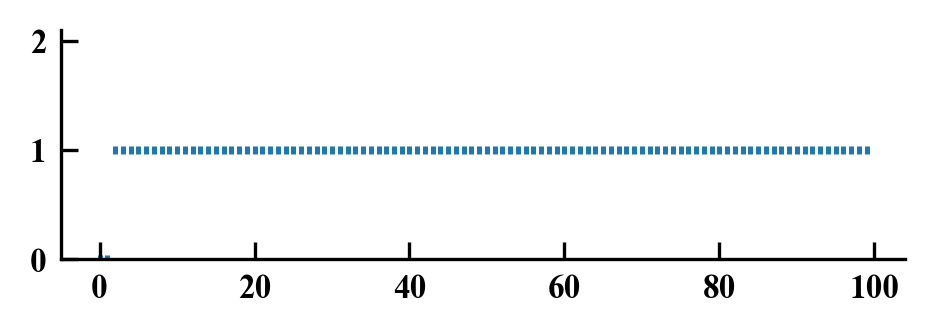

In [4]:
plt.figure(figsize=(3,1), facecolor='white')
plt.scatter(np.arange(100),data["ARM_MONITOR"]["PD"][1.0][2], marker = '|', s = 3)
plt.ylim(0,2.1)

## V2 reward scheme

### Individual runs

In [5]:
data_normal_file_v2 = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'Case_2_difficult', 'non_stationary_bandits_v2_normal.pkl')

with open(data_normal_file_v2, 'rb') as f:
    data_normal_v2 = pickle.load(f)

print(data_normal_v2.keys())

# load PD

data_PD_file_v2 = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'Case_2_difficult', 'non_stationary_bandits_v2_PD.pkl')

with open(data_PD_file_v2, 'rb') as f:
    data_PD_v2 = pickle.load(f)

# load std_DBS

data_std_DBS_file_v2 = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'Case_2_difficult', 'non_stationary_bandits_v2_std_DBS.pkl')

with open(data_std_DBS_file_v2, 'rb') as f:
    data_std_DBS_v2 = pickle.load(f)

# load sector_DBS

data_sector_DBS_file_v2 = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'Case_2_difficult', 'non_stationary_bandits_v2_sector_DBS.pkl')

with open(data_sector_DBS_file_v2, 'rb') as f:
    data_sector_DBS_v2 = pickle.load(f)




dict_keys(['DP_AVG', 'IP_AVG', 'AVG_CARD_PICKS_PER_BIN', 'ARM_CHOSEN_MONITOR', 'REWARD_MONITOR', 'OPTIMAL_PROBS_PER_BIN', 'LAST_BIN_PROBS', 'MEAN_PROB', 'MEAN_REWARD'])


### All

In [6]:
lat_arr = [0.0275, 0.0325, 0.0375, 0.0425, 0.0475]
last_bin_PD_all_v2 = []
last_bin_std_DBS_all_v2 = []
last_bin_sector_DBS_all_v2 = []

mean_PD_all_v2 = []
mean_std_DBS_all_v2 = []
mean_sector_DBS_all_v2 = []

for i in range(len(lat_arr)):
    lat_str = str(lat_arr[i]).replace('.', '_')
    
    data_file = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'Case_2_difficult', 'non_stationary_bandits_v2_data_lat_'+ lat_str + '.pkl')
    with open(data_file, 'rb') as f:
      data = pickle.load(f)
    del_lim_arr = data['DEL_LIM_ARR']
    lat_strength = data['LAT_STRENGTH']
    last_bin_prob_monitor = data['LAST_BIN_PROB_MONITOR']
    mean_prob_monitor = data['MEAN_PROB_OPTIMAL_MONITOR']

    Last_bin_Probs_PD = [last_bin_prob_monitor['PD'][del_lim] for del_lim in del_lim_arr]
    Last_bin_Probs_std_DBS = [last_bin_prob_monitor['STD_DBS'][del_lim] for del_lim in del_lim_arr]
    Last_bin_Probs_sector_DBS = [last_bin_prob_monitor['SECTOR_DBS'][del_lim] for del_lim in del_lim_arr]
    
    mean_Probs_PD = [mean_prob_monitor['PD'][del_lim] for del_lim in del_lim_arr]
    mean_Probs_std_DBS = [mean_prob_monitor['STD_DBS'][del_lim] for del_lim in del_lim_arr]
    mean_Probs_sector_DBS = [mean_prob_monitor['SECTOR_DBS'][del_lim] for del_lim in del_lim_arr]

    last_bin_PD_all_v2.append(Last_bin_Probs_PD)
    last_bin_std_DBS_all_v2.append(Last_bin_Probs_std_DBS)
    last_bin_sector_DBS_all_v2.append(Last_bin_Probs_sector_DBS)

    mean_PD_all_v2.append(mean_Probs_PD)
    mean_std_DBS_all_v2.append(mean_Probs_std_DBS)
    mean_sector_DBS_all_v2.append(mean_Probs_sector_DBS)
        

In [7]:
colors = {'normal':"#054b7c",
          'PD': "#9f0d03ff",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}

colors_PD_shades = ['#C84B3A', '#B33624', '#9F0D03', '#7E0A02', '#5A0601']
colors_std_shades = ['#F2CF9F', '#E0A85C', '#C97A30', '#AD7322', '#7F4A10'] # light -> dark (mid-tone start)
colors_sector_shades = ['#A7E3B9', '#6ED69A', '#2FBF6E', '#038820', '#006012'] # light -> dark (somewhat lighter start)
# colors_PD_shades = ['#EAAFA5', '#D36A4B', '#B73A22', '#9F0D03', '#6E0602'] # light -> dark (somewhat lighter start)

# Mainplot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


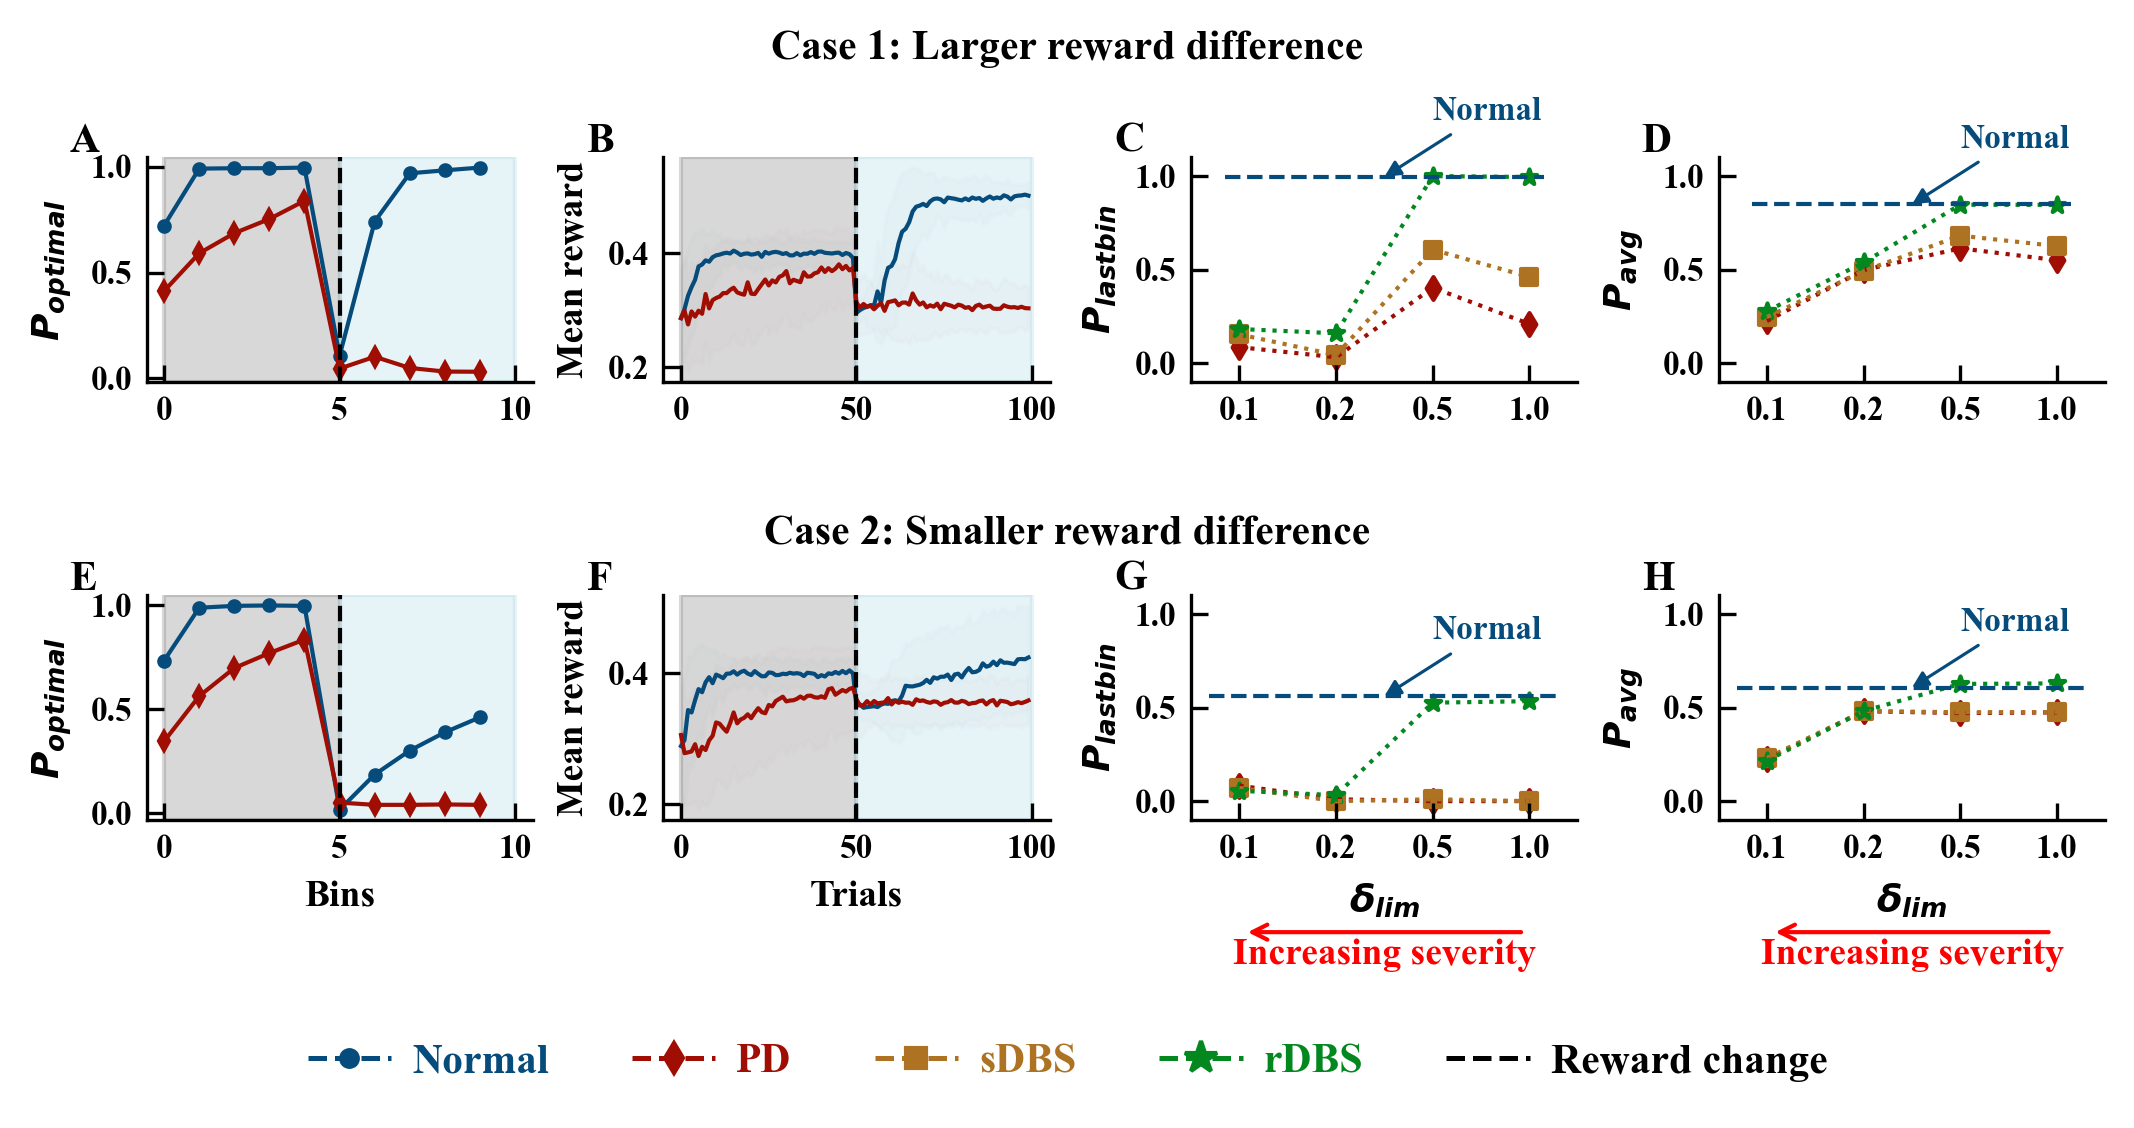

In [13]:
lat_arr_index = 2

fig = plt.figure(figsize=(7, 3), facecolor='white')

gs = fig.add_gridspec(nrows=2, ncols=4, width_ratios=[1,1,1,1], height_ratios=[1, 1], hspace=0.3)

# First row: share x-axis
ax_normal_v1 = fig.add_subplot(gs[0, 0])
ax_PD_v1 = fig.add_subplot(gs[0, 1])
ax_all_last_bin_v1 = fig.add_subplot(gs[0, 2])
ax_all_mean_probs_v1 = fig.add_subplot(gs[0, 3])

# Second row: share x-axis
ax_normal_v2 = fig.add_subplot(gs[1, 0], sharex = ax_normal_v1)
ax_PD_v2 = fig.add_subplot(gs[1, 1], sharex=ax_PD_v1)
ax_all_last_bin_v2 = fig.add_subplot(gs[1, 2], sharex=ax_all_last_bin_v1)
ax_all_mean_probs_v2 = fig.add_subplot(gs[1, 3], sharex=ax_all_mean_probs_v1)

# ************************** First row plots **************************

ax_normal_v1.plot(np.arange(data_normal_v1['OPTIMAL_PROBS_PER_BIN'].shape[0]), data_normal_v1['OPTIMAL_PROBS_PER_BIN'], color=colors['normal'], linewidth=1, alpha=1, marker = '.', markersize=5)
ax_normal_v1.plot(np.arange(data_PD_v1['OPTIMAL_PROBS_PER_BIN'].shape[0]), data_PD_v1['OPTIMAL_PROBS_PER_BIN'], color=colors['PD'], linewidth=1, alpha=1, marker = 'd', markersize=3)
ax_normal_v1.axvline(x=data_normal_v1['OPTIMAL_PROBS_PER_BIN'].shape[0]//2, ymin=0, ymax=1, color='black', linestyle='--', linewidth=1)
# ax_normal_v1.set_xlabel('Bins')
ax_normal_v1.set_ylabel('$P_{optimal}$')


ax_PD_v1.plot(np.arange(data_normal_v1['MEAN_REWARD'].shape[0]), data_normal_v1['MEAN_REWARD'], color=colors['normal'], linewidth=1, alpha=1)
ax_PD_v1.fill_between(np.arange(data_normal_v1['MEAN_REWARD'].shape[0]), data_normal_v1['MEAN_REWARD'] - torch.std(data_normal_v1['REWARD_MONITOR'],0), data_normal_v1['MEAN_REWARD'] + torch.std(data_normal_v1['REWARD_MONITOR'],0), color=colors['normal'], alpha=0.015)
ax_PD_v1.plot(np.arange(data_PD_v1['MEAN_REWARD'].shape[0]), data_PD_v1['MEAN_REWARD'], color=colors['PD'], linewidth=1, alpha=1)
ax_PD_v1.fill_between(np.arange(data_PD_v1['MEAN_REWARD'].shape[0]), data_PD_v1['MEAN_REWARD'] - torch.std(data_PD_v1['REWARD_MONITOR'],0), data_PD_v1['MEAN_REWARD'] + torch.std(data_PD_v1['REWARD_MONITOR'],0), color=colors['PD'], alpha=0.015)
ax_PD_v1.axvline(x=data_PD_v1['MEAN_REWARD'].shape[0]//2, ymin=0, ymax=1, color='black', linestyle='--', linewidth=1)
# ax_PD_v1.set_xlabel('Trials')
ax_PD_v1.set_ylabel('Mean reward')

# v1 plots last bin

ax_all_last_bin_v1.scatter(np.arange(4), last_bin_PD_all_v1[lat_arr_index], marker='d', color=colors['PD'], s=15)
ax_all_last_bin_v1.scatter(np.arange(4), last_bin_std_DBS_all_v1[lat_arr_index], marker='s', color=colors['std_DBS'], s=15)
ax_all_last_bin_v1.scatter(np.arange(4), last_bin_sector_DBS_all_v1[lat_arr_index], marker='*', color=colors['sector_DBS'], s=15)
ax_all_last_bin_v1.plot(np.arange(4), last_bin_PD_all_v1[lat_arr_index], color=colors['PD'], linewidth=1, alpha=1, linestyle='dotted')
ax_all_last_bin_v1.plot(np.arange(4), last_bin_std_DBS_all_v1[lat_arr_index], color=colors['std_DBS'], linewidth=1, alpha=1, linestyle='dotted')
ax_all_last_bin_v1.plot(np.arange(4), last_bin_sector_DBS_all_v1[lat_arr_index], color=colors['sector_DBS'], linewidth=1, alpha=1, linestyle='dotted')
# ax_all_last_bin_v1.set_xlabel('$\\delta_{lim}$')
ax_all_last_bin_v1.set_ylabel('$P_{last bin}$')
ax_all_last_bin_v1.set_xticks(np.arange(4), del_lim_arr)
ax_all_last_bin_v1.set_ylim(-0.1,1.1)

x_min, x_max = ax_all_last_bin_v1.get_xlim()
ax_all_last_bin_v1.hlines(data_normal_v1['OPTIMAL_PROBS_PER_BIN'][-1], x_min, x_max, color=colors['normal'], linestyle='--', linewidth=1.0)
x_ann = x_min + 0.5 * (x_max - x_min)               # near left/y-axis
y_ann = data_normal_v1['OPTIMAL_PROBS_PER_BIN'][-1] 
y_text = data_normal_v1['OPTIMAL_PROBS_PER_BIN'][-1] + 0.35

ax_all_last_bin_v1.annotate(
    'Normal',
    xy=(x_ann, y_ann),
    xytext=(x_ann + 0.5, y_text),
    arrowprops=dict(arrowstyle='-|>', color=colors['normal'], lw=0.75, shrinkA=0, shrinkB=0),
    fontsize=8, fontweight='bold', color=colors['normal'], va='center'
)

# v1 plots for mean

ax_all_mean_probs_v1.scatter(np.arange(4), mean_PD_all_v1[lat_arr_index], marker='d', color=colors['PD'], s=15)
ax_all_mean_probs_v1.scatter(np.arange(4), mean_std_DBS_all_v1[lat_arr_index], marker='s', color=colors['std_DBS'], s=15)
ax_all_mean_probs_v1.scatter(np.arange(4), mean_sector_DBS_all_v1[lat_arr_index], marker='*', color=colors['sector_DBS'], s=15)
ax_all_mean_probs_v1.plot(np.arange(4), mean_PD_all_v1[lat_arr_index], color=colors['PD'], linewidth=1, alpha=1, linestyle='dotted')
ax_all_mean_probs_v1.plot(np.arange(4), mean_std_DBS_all_v1[lat_arr_index], color=colors['std_DBS'], linewidth=1, alpha=1, linestyle='dotted')
ax_all_mean_probs_v1.plot(np.arange(4), mean_sector_DBS_all_v1[lat_arr_index], color=colors['sector_DBS'], linewidth=1, alpha=1, linestyle='dotted')
# ax_all_mean_probs_v1.set_xlabel('$\\delta_{lim}$')
ax_all_mean_probs_v1.set_ylabel('$P_{avg}$')
ax_all_mean_probs_v1.set_xticks(np.arange(4), del_lim_arr)
ax_all_mean_probs_v1.set_ylim(-0.1,1.1)

x_min, x_max = ax_all_mean_probs_v1.get_xlim()
ax_all_mean_probs_v1.hlines(torch.mean(data_normal_v1['OPTIMAL_PROBS_PER_BIN']), x_min, x_max, color=colors['normal'], linestyle='--', linewidth=1.0)
x_ann = x_min + 0.5 * (x_max - x_min)               # near left/y-axis
y_ann = torch.mean(data_normal_v1['OPTIMAL_PROBS_PER_BIN'])
y_text = torch.mean(data_normal_v1['OPTIMAL_PROBS_PER_BIN']) + 0.35

ax_all_mean_probs_v1.annotate(
    'Normal',
    xy=(x_ann, y_ann),
    xytext=(x_ann + 0.5, y_text),
    arrowprops=dict(arrowstyle='-|>', color=colors['normal'], lw=0.75, shrinkA=0, shrinkB=0),
    fontsize=8, fontweight='bold', color=colors['normal'], va='center'
)

# ************************* second row plots *************************

ax_normal_v2.plot(np.arange(data_normal_v2['OPTIMAL_PROBS_PER_BIN'].shape[0]), data_normal_v2['OPTIMAL_PROBS_PER_BIN'], color=colors['normal'], linewidth=1, alpha=1, marker = '.', markersize=5)
ax_normal_v2.plot(np.arange(data_PD_v2['OPTIMAL_PROBS_PER_BIN'].shape[0]), data_PD_v2['OPTIMAL_PROBS_PER_BIN'], color=colors['PD'], linewidth=1, alpha=1, marker = 'd', markersize=3)
ax_normal_v2.axvline(x=data_normal_v2['OPTIMAL_PROBS_PER_BIN'].shape[0]//2, ymin=0, ymax=1, color='black', linestyle='--', linewidth=1)
ax_normal_v2.set_xlabel('Bins')
ax_normal_v2.set_ylabel('$P_{optimal}$')

ax_PD_v2.plot(np.arange(data_normal_v2['MEAN_REWARD'].shape[0]), data_normal_v2['MEAN_REWARD'], color=colors['normal'], linewidth=1, alpha=1)
ax_PD_v2.fill_between(np.arange(data_normal_v2['MEAN_REWARD'].shape[0]), data_normal_v2['MEAN_REWARD'] - torch.std(data_normal_v2['REWARD_MONITOR'],0), data_normal_v2['MEAN_REWARD'] + torch.std(data_normal_v2['REWARD_MONITOR'],0), color=colors['normal'], alpha=0.015)
ax_PD_v2.plot(np.arange(data_PD_v2['MEAN_REWARD'].shape[0]), data_PD_v2['MEAN_REWARD'], color=colors['PD'], linewidth=1, alpha=1)
ax_PD_v2.fill_between(np.arange(data_PD_v2['MEAN_REWARD'].shape[0]), data_PD_v2['MEAN_REWARD'] - torch.std(data_PD_v2['REWARD_MONITOR'],0), data_PD_v2['MEAN_REWARD'] + torch.std(data_PD_v2['REWARD_MONITOR'],0), color=colors['PD'], alpha=0.015)
ax_PD_v2.axvline(x=data_PD_v2['MEAN_REWARD'].shape[0]//2, ymin=0, ymax=1, color='black', linestyle='--', linewidth=1)
ax_PD_v2.set_xlabel('Trials')
ax_PD_v2.set_ylabel('Mean reward')



# v2 plots last bin

ax_all_last_bin_v2.scatter(np.arange(4), last_bin_PD_all_v2[lat_arr_index], marker='d', color=colors['PD'], s=15)
ax_all_last_bin_v2.scatter(np.arange(4), last_bin_std_DBS_all_v2[lat_arr_index], marker='s', color=colors['std_DBS'], s=15)
ax_all_last_bin_v2.scatter(np.arange(4), last_bin_sector_DBS_all_v2[lat_arr_index], marker='*', color=colors['sector_DBS'], s=15)
ax_all_last_bin_v2.plot(np.arange(4), last_bin_PD_all_v2[lat_arr_index], color=colors['PD'], linewidth=1, alpha=1, linestyle='dotted')
ax_all_last_bin_v2.plot(np.arange(4), last_bin_std_DBS_all_v2[lat_arr_index], color=colors['std_DBS'], linewidth=1, alpha=1, linestyle = 'dotted')
ax_all_last_bin_v2.plot(np.arange(4), last_bin_sector_DBS_all_v2[lat_arr_index], color=colors['sector_DBS'], linewidth=1, alpha=1,linestyle='dotted')
ax_all_last_bin_v2.set_xlabel('$\\delta_{lim}$')
ax_all_last_bin_v2.set_ylabel('$P_{last bin}$')
ax_all_last_bin_v2.set_xticks(np.arange(4), del_lim_arr)
ax_all_last_bin_v2.set_ylim(-0.1,1.1)

x_min, x_max = ax_all_last_bin_v2.get_xlim()
ax_all_last_bin_v2.hlines(data_normal_v2['OPTIMAL_PROBS_PER_BIN'][-1]+0.1, x_min, x_max, color=colors['normal'], linestyle='--', linewidth=1.0)
x_ann = x_min + 0.5 * (x_max - x_min)               # near left/y-axis
y_ann = data_normal_v2['OPTIMAL_PROBS_PER_BIN'][-1] + 0.1
y_text = data_normal_v2['OPTIMAL_PROBS_PER_BIN'][-1] + 0.45

ax_all_last_bin_v2.annotate(
    'Normal',
    xy=(x_ann, y_ann),
    xytext=(x_ann + 0.5, y_text),
    arrowprops=dict(arrowstyle='-|>', color=colors['normal'], lw=0.75, shrinkA=0, shrinkB=0),
    fontsize=8, fontweight='bold', color=colors['normal'], va='center'
)


# v2 plots for mean

ax_all_mean_probs_v2.scatter(np.arange(4), mean_PD_all_v2[lat_arr_index], marker='d', color=colors['PD'], s=15)
ax_all_mean_probs_v2.scatter(np.arange(4), mean_std_DBS_all_v2[lat_arr_index], marker='s', color=colors['std_DBS'], s=15)
ax_all_mean_probs_v2.scatter(np.arange(4), mean_sector_DBS_all_v2[lat_arr_index], marker='*', color=colors['sector_DBS'], s=15)
ax_all_mean_probs_v2.plot(np.arange(4), mean_PD_all_v2[lat_arr_index], color=colors['PD'], linewidth=1, alpha=1, linestyle='dotted')
ax_all_mean_probs_v2.plot(np.arange(4), mean_std_DBS_all_v2[lat_arr_index], color=colors['std_DBS'], linewidth=1, alpha=1, linestyle = 'dotted')
ax_all_mean_probs_v2.plot(np.arange(4), mean_sector_DBS_all_v2[lat_arr_index], color=colors['sector_DBS'], linewidth=1, alpha=1, linestyle='dotted')
ax_all_mean_probs_v2.set_xlabel('$\\delta_{lim}$')
ax_all_mean_probs_v2.set_ylabel('$P_{avg}$')
ax_all_mean_probs_v2.set_xticks(np.arange(4), del_lim_arr)
ax_all_mean_probs_v2.set_ylim(-0.1, 1.1)

x_min, x_max = ax_all_mean_probs_v2.get_xlim()
ax_all_mean_probs_v2.hlines(torch.mean(data_normal_v2['OPTIMAL_PROBS_PER_BIN']), x_min, x_max, color=colors['normal'], linestyle='--', linewidth=1.0)
x_ann = x_min + 0.5 * (x_max - x_min)               # near left/y-axis
y_ann = torch.mean(data_normal_v2['OPTIMAL_PROBS_PER_BIN'])
y_text = torch.mean(data_normal_v2['OPTIMAL_PROBS_PER_BIN']) + 0.35

ax_all_mean_probs_v2.annotate(
    'Normal',
    xy=(x_ann, y_ann),
    xytext=(x_ann + 0.5, y_text),
    arrowprops=dict(arrowstyle='-|>', color=colors['normal'], lw=0.75, shrinkA=0, shrinkB=0),
    fontsize=8, fontweight='bold', color=colors['normal'], va='center'
)
# Add shading after creating the axes but before plotting

# For v1 normal
mid_point_v1_normal = data_normal_v1['OPTIMAL_PROBS_PER_BIN'].shape[0] // 2
ax_normal_v1.axvspan(0, mid_point_v1_normal, color='gray', alpha=0.3)
ax_normal_v1.axvspan(mid_point_v1_normal, data_normal_v1['OPTIMAL_PROBS_PER_BIN'].shape[0], color='#ADD8E6', alpha=0.3)  # mild blue pastel

# For v1 PD
mid_point_v1_pd = data_PD_v1['MEAN_REWARD'].shape[0] // 2
ax_PD_v1.axvspan(0, mid_point_v1_pd, color='gray', alpha=0.3)
ax_PD_v1.axvspan(mid_point_v1_pd, data_PD_v1['MEAN_REWARD'].shape[0], color='#ADD8E6', alpha=0.3)
# 
# For v2 normal
mid_point_v2_normal = data_normal_v2['OPTIMAL_PROBS_PER_BIN'].shape[0] // 2
ax_normal_v2.axvspan(0, mid_point_v2_normal, color='gray', alpha=0.3)
ax_normal_v2.axvspan(mid_point_v2_normal, data_normal_v2['OPTIMAL_PROBS_PER_BIN'].shape[0], color='#ADD8E6', alpha=0.3)

# For v2 PD
mid_point_v2_pd = data_PD_v2['MEAN_REWARD'].shape[0] // 2
ax_PD_v2.axvspan(0, mid_point_v2_pd, color='gray', alpha=0.3)
ax_PD_v2.axvspan(mid_point_v2_pd, data_PD_v2['MEAN_REWARD'].shape[0], color='#ADD8E6', alpha=0.3)

subplot_axes = [
    ax_normal_v1, ax_PD_v1, ax_all_last_bin_v1, ax_all_mean_probs_v1,
    ax_normal_v2, ax_PD_v2, ax_all_last_bin_v2, ax_all_mean_probs_v2
]
labels = list('ABCDEFGH')
for ax, label in zip(subplot_axes, labels):
    ax.text(-0.2, 1.15, label, transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')

# Add a single legend for all conditions at the bottom of the figure
handles = [
    Line2D([0], [0], color=colors['normal'], marker='.', linestyle='--', label='Normal', markersize = 8),
    Line2D([0], [0], color=colors['PD'], marker='d', linestyle='--', label='PD'),
    Line2D([0], [0], color=colors['std_DBS'], marker='s', linestyle='--', label='sDBS'),
    Line2D([0], [0], color=colors['sector_DBS'], marker='*', linestyle='--', label='rDBS', markersize = 8),
    Line2D([0], [0], color = 'black', linestyle='--', label = "Reward change")
]
legend = fig.legend(handles=handles, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.15), frameon=False, fontsize=10)
for txt, col in zip(legend.get_texts(), [colors['normal'], colors['PD'], colors['std_DBS'], colors['sector_DBS'], 'black']):
    txt.set_color(col)


x_values = np.arange(len(del_lim_arr))
x_start = x_values[-1] 
x_end = x_values[0] 
y_pos = -0.5
ax_all_mean_probs_v2.annotate(
    '',  # No text at the arrow tip
    xy=(x_end, y_pos),           # Arrow tip coordinates (end point)
    xytext=(x_start, y_pos),     # Text and arrow tail coordinates (start point)
    xycoords=('data', 'axes fraction'), # Use data coords for x, axes fraction for y
    textcoords=('data', 'axes fraction'),
    arrowprops=dict(
        arrowstyle="->",         # Style of the arrow head
        color='red',           # Color of the arrow
        linewidth=1
    )
)
# 
# 4. Add the text at the center of the arrow.
ax_all_mean_probs_v2.annotate(
    'Increasing severity',
    xy=((x_start + x_end) / 2, y_pos-0.1), # Center point of the arrow
    xycoords=('data', 'axes fraction'),
    ha='center',                 # Horizontal alignment
    va='center',                 # Vertical alignment (center on the arrow line)
    fontsize=9,
    color='red'
)


x_values = np.arange(len(del_lim_arr))
x_start = x_values[-1] 
x_end = x_values[0] 
y_pos = -0.5
ax_all_last_bin_v2.annotate(
    '',  # No text at the arrow tip
    xy=(x_end, y_pos),           # Arrow tip coordinates (end point)
    xytext=(x_start, y_pos),     # Text and arrow tail coordinates (start point)
    xycoords=('data', 'axes fraction'), # Use data coords for x, axes fraction for y
    textcoords=('data', 'axes fraction'),
    arrowprops=dict(
        arrowstyle="->",         # Style of the arrow head
        color='red',           # Color of the arrow
        linewidth=1
    )
)
# 
# 4. Add the text at the center of the arrow.
ax_all_last_bin_v2.annotate(
    'Increasing severity',
    xy=((x_start + x_end) / 2, y_pos-0.1), # Center point of the arrow
    xycoords=('data', 'axes fraction'),
    ha='center',                 # Horizontal alignment
    va='center',                 # Vertical alignment (center on the arrow line)
    fontsize=9,
    color='red'
)

# ---- Row titles ----
fig.text(
    0.5, 1.06, 'Case 1: Larger reward difference',
    fontsize=10,
    fontweight='bold',
    ha='center',
    va='top'
)

# Middle (just above second row)
fig.text(
    0.5, 0.52, 'Case 2: Smaller reward difference',
    fontsize=10,
    fontweight='bold',
    ha='center',
    va='top'
)
# Save figs
plt.savefig("NSB_results.svg", format="svg",  bbox_inches="tight",pad_inches=0.05)
plt.savefig("NSB_results.png", format="png", bbox_inches="tight",pad_inches=0.05)
plt.savefig("NSB_results.pdf", format="pdf", bbox_inches="tight",pad_inches=0.05)
plt.savefig("NSB_results.tiff",format="tiff",dpi=600,bbox_inches="tight",pad_inches=0.05)
plt.savefig("NSB_results.eps",format="eps",bbox_inches="tight",pad_inches=0.05)



plt.show()

# Supplementary plot

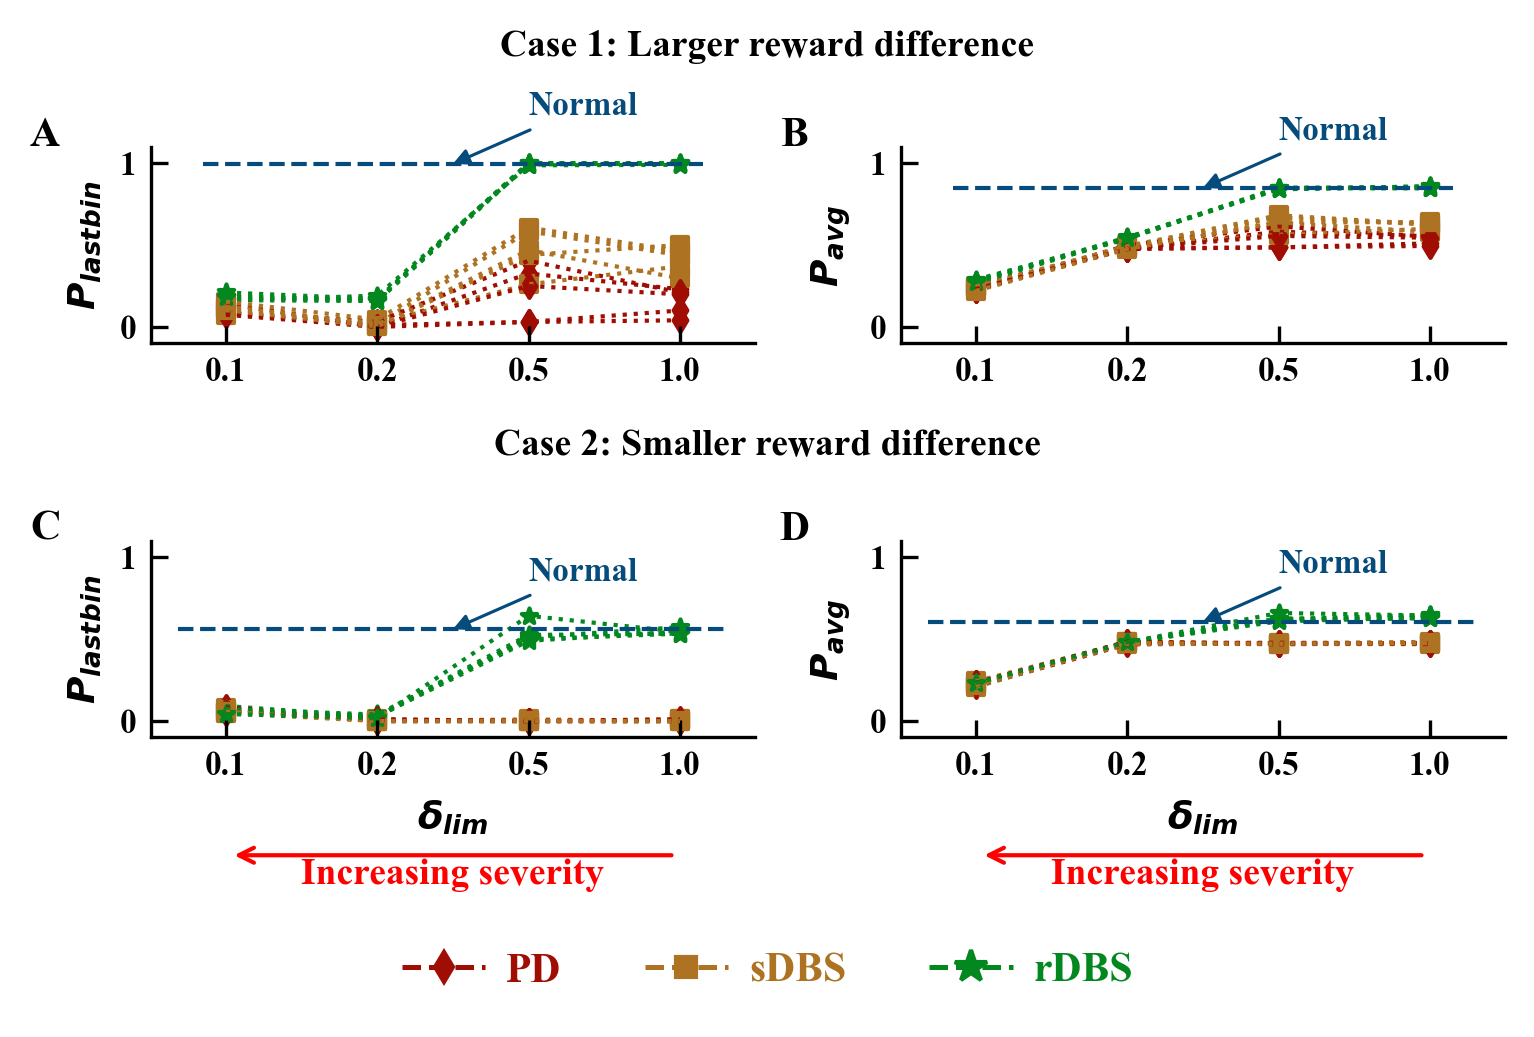

In [16]:
fig = plt.figure(figsize=(5, 2.75), facecolor='white')

gs = fig.add_gridspec(nrows=2, ncols=2, width_ratios=[1,1], height_ratios=[1, 1], hspace=0.3)

# Second row: share x-axis
ax_all_last_bin_v1 = fig.add_subplot(gs[0, 0])
ax_all_mean_probs_v1 = fig.add_subplot(gs[0, 1])

# First row: share x-axis
ax_all_last_bin_v2 = fig.add_subplot(gs[1, 0], sharex=ax_all_last_bin_v1)
ax_all_mean_probs_v2 = fig.add_subplot(gs[1, 1], sharex=ax_all_mean_probs_v1)

# ************************** First row plots ************************

# v1 plots last bin
for i in range(5):
    ax_all_last_bin_v1.scatter(np.arange(4), last_bin_PD_all_v1[i], marker='d', color=colors['PD'], s=15)
    ax_all_last_bin_v1.scatter(np.arange(4), last_bin_std_DBS_all_v1[i], marker='s', color=colors['std_DBS'], s=15)
    ax_all_last_bin_v1.scatter(np.arange(4), last_bin_sector_DBS_all_v1[i], marker='*', color=colors['sector_DBS'], s=15)
    ax_all_last_bin_v1.plot(np.arange(4), last_bin_PD_all_v1[i], color=colors['PD'], linewidth=1, alpha=1, linestyle='dotted')
    ax_all_last_bin_v1.plot(np.arange(4), last_bin_std_DBS_all_v1[i], color=colors['std_DBS'], linewidth=1, alpha=1, linestyle='dotted')
    ax_all_last_bin_v1.plot(np.arange(4), last_bin_sector_DBS_all_v1[i], color=colors['sector_DBS'], linewidth=1, alpha=1, linestyle='dotted')
    # ax_all_last_bin_v1.set_xlabel('$\\delta_{lim}$')
    ax_all_last_bin_v1.set_ylabel('$P_{last bin}$')
    ax_all_last_bin_v1.set_xticks(np.arange(4), del_lim_arr)
    ax_all_last_bin_v1.set_ylim(-0.1,1.1)

x_min, x_max = ax_all_last_bin_v1.get_xlim()
ax_all_last_bin_v1.hlines(data_normal_v1['OPTIMAL_PROBS_PER_BIN'][-1], x_min, x_max, color=colors['normal'], linestyle='--', linewidth=1.0)
x_ann = x_min + 0.5 * (x_max - x_min)               # near left/y-axis
y_ann = data_normal_v1['OPTIMAL_PROBS_PER_BIN'][-1] 
y_text = data_normal_v1['OPTIMAL_PROBS_PER_BIN'][-1] + 0.35

ax_all_last_bin_v1.annotate(
    'Normal',
    xy=(x_ann, y_ann),
    xytext=(x_ann + 0.5, y_text),
    arrowprops=dict(arrowstyle='-|>', color=colors['normal'], lw=0.75, shrinkA=0, shrinkB=0),
    fontsize=8, fontweight='bold', color=colors['normal'], va='center'
)

# v1 plots for mean
for i in range(5):
    ax_all_mean_probs_v1.scatter(np.arange(4), mean_PD_all_v1[i], marker='d', color=colors['PD'], s=15)
    ax_all_mean_probs_v1.scatter(np.arange(4), mean_std_DBS_all_v1[i], marker='s', color=colors['std_DBS'], s=15)
    ax_all_mean_probs_v1.scatter(np.arange(4), mean_sector_DBS_all_v1[i], marker='*', color=colors['sector_DBS'], s=15)
    ax_all_mean_probs_v1.plot(np.arange(4), mean_PD_all_v1[i], color=colors['PD'], linewidth=1, alpha=1, linestyle='dotted')
    ax_all_mean_probs_v1.plot(np.arange(4), mean_std_DBS_all_v1[i], color=colors['std_DBS'], linewidth=1, alpha=1, linestyle='dotted')
    ax_all_mean_probs_v1.plot(np.arange(4), mean_sector_DBS_all_v1[i], color=colors['sector_DBS'], linewidth=1, alpha=1, linestyle='dotted')
    # ax_all_mean_probs_v1.set_xlabel('$\\delta_{lim}$')
    ax_all_mean_probs_v1.set_ylabel('$P_{avg}$')
    ax_all_mean_probs_v1.set_xticks(np.arange(4), del_lim_arr)
    ax_all_mean_probs_v1.set_ylim(-0.1,1.1)

x_min, x_max = ax_all_mean_probs_v1.get_xlim()
ax_all_mean_probs_v1.hlines(torch.mean(data_normal_v1['OPTIMAL_PROBS_PER_BIN']), x_min, x_max, color=colors['normal'], linestyle='--', linewidth=1.0)
x_ann = x_min + 0.5 * (x_max - x_min)               # near left/y-axis
y_ann = torch.mean(data_normal_v1['OPTIMAL_PROBS_PER_BIN'])
y_text = torch.mean(data_normal_v1['OPTIMAL_PROBS_PER_BIN']) + 0.35
ax_all_mean_probs_v1.annotate(
    'Normal',
    xy=(x_ann, y_ann),
    xytext=(x_ann + 0.5, y_text),
    arrowprops=dict(arrowstyle='-|>', color=colors['normal'], lw=0.75, shrinkA=0, shrinkB=0),
    fontsize=8, fontweight='bold', color=colors['normal'], va='center'
)

# ************************* second row plots *************************


# v2 plots last bin
for i in range(5):
    ax_all_last_bin_v2.scatter(np.arange(4), last_bin_PD_all_v2[i], marker='d', color=colors['PD'], s=15)
    ax_all_last_bin_v2.scatter(np.arange(4), last_bin_std_DBS_all_v2[i], marker='s', color=colors['std_DBS'], s=15)
    ax_all_last_bin_v2.scatter(np.arange(4), last_bin_sector_DBS_all_v2[i], marker='*', color=colors['sector_DBS'], s=15)
    ax_all_last_bin_v2.plot(np.arange(4), last_bin_PD_all_v2[i], color=colors['PD'], linewidth=1, alpha=1, linestyle='dotted')
    ax_all_last_bin_v2.plot(np.arange(4), last_bin_std_DBS_all_v2[i], color=colors['std_DBS'], linewidth=1, alpha=1, linestyle = 'dotted')
    ax_all_last_bin_v2.plot(np.arange(4), last_bin_sector_DBS_all_v2[i], color=colors['sector_DBS'], linewidth=1, alpha=1,linestyle='dotted')
    ax_all_last_bin_v2.set_xlabel('$\\delta_{lim}$')
    ax_all_last_bin_v2.set_ylabel('$P_{last bin}$')
    ax_all_last_bin_v2.set_xticks(np.arange(4), del_lim_arr)
    ax_all_last_bin_v2.set_ylim(-0.1,1.1)

x_min, x_max = ax_all_last_bin_v2.get_xlim()
ax_all_last_bin_v2.hlines(data_normal_v2['OPTIMAL_PROBS_PER_BIN'][-1]+0.1, x_min, x_max, color=colors['normal'], linestyle='--', linewidth=1.0)
x_ann = x_min + 0.5 * (x_max - x_min)               # near left/y-axis
y_ann = data_normal_v2['OPTIMAL_PROBS_PER_BIN'][-1] + 0.1
y_text = data_normal_v2['OPTIMAL_PROBS_PER_BIN'][-1] + 0.45

ax_all_last_bin_v2.annotate(
    'Normal',
    xy=(x_ann, y_ann),
    xytext=(x_ann + 0.5, y_text),
    arrowprops=dict(arrowstyle='-|>', color=colors['normal'], lw=0.75, shrinkA=0, shrinkB=0),
    fontsize=8, fontweight='bold', color=colors['normal'], va='center'
)


# v2 plots for mean
for i in range(5):
    ax_all_mean_probs_v2.scatter(np.arange(4), mean_PD_all_v2[i], marker='d', color=colors['PD'], s=15)
    ax_all_mean_probs_v2.scatter(np.arange(4), mean_std_DBS_all_v2[i], marker='s', color=colors['std_DBS'], s=15)
    ax_all_mean_probs_v2.scatter(np.arange(4), mean_sector_DBS_all_v2[i], marker='*', color=colors['sector_DBS'], s=15)
    ax_all_mean_probs_v2.plot(np.arange(4), mean_PD_all_v2[i], color=colors['PD'], linewidth=1, alpha=1, linestyle='dotted')
    ax_all_mean_probs_v2.plot(np.arange(4), mean_std_DBS_all_v2[i], color=colors['std_DBS'], linewidth=1, alpha=1, linestyle = 'dotted')
    ax_all_mean_probs_v2.plot(np.arange(4), mean_sector_DBS_all_v2[i], color=colors['sector_DBS'], linewidth=1, alpha=1, linestyle='dotted')
    ax_all_mean_probs_v2.set_xlabel('$\\delta_{lim}$')
    ax_all_mean_probs_v2.set_ylabel('$P_{avg}$')
    ax_all_mean_probs_v2.set_xticks(np.arange(4), del_lim_arr)
    ax_all_mean_probs_v2.set_ylim(-0.1, 1.1)

x_min, x_max = ax_all_mean_probs_v2.get_xlim()
ax_all_mean_probs_v2.hlines(torch.mean(data_normal_v2['OPTIMAL_PROBS_PER_BIN']), x_min, x_max, color=colors['normal'], linestyle='--', linewidth=1.0)
x_ann = x_min + 0.5 * (x_max - x_min)               # near left/y-axis
y_ann = torch.mean(data_normal_v2['OPTIMAL_PROBS_PER_BIN'])
y_text = torch.mean(data_normal_v2['OPTIMAL_PROBS_PER_BIN']) + 0.35

ax_all_mean_probs_v2.annotate(
    'Normal',
    xy=(x_ann, y_ann),
    xytext=(x_ann + 0.5, y_text),
    arrowprops=dict(arrowstyle='-|>', color=colors['normal'], lw=0.75, shrinkA=0, shrinkB=0),
    fontsize=8, fontweight='bold', color=colors['normal'], va='center'
)
# Add shading after creating the axes but before plotting

# For v1 normal
mid_point_v1_normal = data_normal_v1['OPTIMAL_PROBS_PER_BIN'].shape[0] // 2
ax_normal_v1.axvspan(0, mid_point_v1_normal, color='gray', alpha=0.3)
ax_normal_v1.axvspan(mid_point_v1_normal, data_normal_v1['OPTIMAL_PROBS_PER_BIN'].shape[0], color='#ADD8E6', alpha=0.3)  # mild blue pastel

# For v1 PD
mid_point_v1_pd = data_PD_v1['MEAN_REWARD'].shape[0] // 2
ax_PD_v1.axvspan(0, mid_point_v1_pd, color='gray', alpha=0.3)
ax_PD_v1.axvspan(mid_point_v1_pd, data_PD_v1['MEAN_REWARD'].shape[0], color='#ADD8E6', alpha=0.3)
# 
# For v2 normal
mid_point_v2_normal = data_normal_v2['OPTIMAL_PROBS_PER_BIN'].shape[0] // 2
ax_normal_v2.axvspan(0, mid_point_v2_normal, color='gray', alpha=0.3)
ax_normal_v2.axvspan(mid_point_v2_normal, data_normal_v2['OPTIMAL_PROBS_PER_BIN'].shape[0], color='#ADD8E6', alpha=0.3)

# For v2 PD
mid_point_v2_pd = data_PD_v2['MEAN_REWARD'].shape[0] // 2
ax_PD_v2.axvspan(0, mid_point_v2_pd, color='gray', alpha=0.3)
ax_PD_v2.axvspan(mid_point_v2_pd, data_PD_v2['MEAN_REWARD'].shape[0], color='#ADD8E6', alpha=0.3)

subplot_axes = [
    ax_all_last_bin_v1, ax_all_mean_probs_v1,
    ax_all_last_bin_v2, ax_all_mean_probs_v2
]
labels = list('ABCDEFGH')
for ax, label in zip(subplot_axes, labels):
    ax.text(-0.2, 1.15, label, transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')

# Add a single legend for all conditions at the bottom of the figure
handles = [
    Line2D([0], [0], color=colors['PD'], marker='d', linestyle='--', label='PD'),
    Line2D([0], [0], color=colors['std_DBS'], marker='s', linestyle='--', label='sDBS'),
    Line2D([0], [0], color=colors['sector_DBS'], marker='*', linestyle='--', label='rDBS', markersize = 8),
]
legend = fig.legend(handles=handles, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.15), frameon=False, fontsize=10)
for txt, col in zip(legend.get_texts(), [colors['PD'], colors['std_DBS'], colors['sector_DBS']]):
    txt.set_color(col)



x_values = np.arange(len(del_lim_arr))
x_start = x_values[-1] 
x_end = x_values[0] 
y_pos = -0.6
ax_all_mean_probs_v2.annotate(
    '',  # No text at the arrow tip
    xy=(x_end, y_pos),           # Arrow tip coordinates (end point)
    xytext=(x_start, y_pos),     # Text and arrow tail coordinates (start point)
    xycoords=('data', 'axes fraction'), # Use data coords for x, axes fraction for y
    textcoords=('data', 'axes fraction'),
    arrowprops=dict(
        arrowstyle="->",         # Style of the arrow head
        color='red',           # Color of the arrow
        linewidth=1
    )
)
# 
# 4. Add the text at the center of the arrow.
ax_all_mean_probs_v2.annotate(
    'Increasing severity',
    xy=((x_start + x_end) / 2, y_pos-0.1), # Center point of the arrow
    xycoords=('data', 'axes fraction'),
    ha='center',                 # Horizontal alignment
    va='center',                 # Vertical alignment (center on the arrow line)
    fontsize=9,
    color='red'
)


x_values = np.arange(len(del_lim_arr))
x_start = x_values[-1] 
x_end = x_values[0] 
y_pos = -0.6
ax_all_last_bin_v2.annotate(
    '',  # No text at the arrow tip
    xy=(x_end, y_pos),           # Arrow tip coordinates (end point)
    xytext=(x_start, y_pos),     # Text and arrow tail coordinates (start point)
    xycoords=('data', 'axes fraction'), # Use data coords for x, axes fraction for y
    textcoords=('data', 'axes fraction'),
    arrowprops=dict(
        arrowstyle="->",         # Style of the arrow head
        color='red',           # Color of the arrow
        linewidth=1
    )
)
# 
# 4. Add the text at the center of the arrow.
ax_all_last_bin_v2.annotate(
    'Increasing severity',
    xy=((x_start + x_end) / 2, y_pos-0.1), # Center point of the arrow
    xycoords=('data', 'axes fraction'),
    ha='center',                 # Horizontal alignment
    va='center',                 # Vertical alignment (center on the arrow line)
    fontsize=9,
    color='red'
)
plt.subplots_adjust(wspace=0.4, hspace=1.1)
# ---- Row titles ----
fig.text(
    0.5, 1.06, 'Case 1: Larger reward difference',
    fontsize=9,
    fontweight='bold',
    ha='center',
    va='top'
)

# Middle (just above second row)
fig.text(
    0.5, 0.575, 'Case 2: Smaller reward difference',
    fontsize=9,
    fontweight='bold',
    ha='center',
    va='top'
)


# Save figs
plt.savefig("Supp_NSB_plot.svg", format="svg",  bbox_inches="tight",pad_inches=0.05)
plt.savefig("Supp_NSB_plot.png", format="png", bbox_inches="tight",pad_inches=0.05)
plt.savefig("Supp_NSB_plot.pdf", format="pdf", bbox_inches="tight",pad_inches=0.05)
plt.savefig("Supp_NSB_plot.tiff",format="tiff",dpi=600,bbox_inches="tight",pad_inches=0.05)
plt.savefig("Supp_NSB_plot.eps",format="eps",bbox_inches="tight",pad_inches=0.05)

plt.show()